In [1]:
# Menampilkan file yang diunggah
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pickle
import io

In [2]:
df = pd.read_csv("Data Historis INDF.csv", delimiter=";")
# Drop unwanted unnamed columns if present
df = df[['Tanggal', 'Terakhir']]
df['Terakhir'] = (df['Terakhir']*1000).astype(int)
df

,Tanggal,Terakhir
0,23/10/15,6225
1,26/10/15,6225
2,27/10/15,6200
3,28/10/15,6075
4,29/10/15,5650
...,...,...
2410,16/10/25,7075
2411,17/10/25,7125
2412,20/10/25,7250
2413,21/10/25,7275


In [3]:
# Menampilkan data
print("Historis Saham INDF:")
print(f"\nShape data: {df.shape}")
df

Historis Saham INDF:

Shape data: (2415, 2)


,Tanggal,Terakhir
0,23/10/15,6225
1,26/10/15,6225
2,27/10/15,6200
3,28/10/15,6075
4,29/10/15,5650
...,...,...
2410,16/10/25,7075
2411,17/10/25,7125
2412,20/10/25,7250
2413,21/10/25,7275


In [4]:
# 1. Parsing Tanggal dengan format eksplisit (Menghilangkan UserWarning)
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%y', errors='coerce')

# 2. Hapus jika ada baris yang gagal jadi tanggal (NaN)
df = df.dropna(subset=['Tanggal'])

# 3. Urutkan dan tangani duplikat
df = df.sort_values('Tanggal')
df = df.groupby('Tanggal')['Terakhir'].mean().reset_index()

# 4. Set Index
df.set_index('Tanggal', inplace=True)

# 5. Buat range weekday (freq='B')
all_weekdays = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')

# 6. Reindex
df = df.reindex(all_weekdays)

# 7. Interpolasi dan Backfill (Menghilangkan FutureWarning)
df['Terakhir'] = df['Terakhir'].interpolate(method='linear')
df['Terakhir'] = df['Terakhir'].bfill()

# 8. Reset Index
df = df.reset_index().rename(columns={'index': 'Tanggal'})

# 9. Ubah kembali ke integer setelah interpolasi selesai
df['Terakhir'] = df['Terakhir'].round().astype(int)

print("--- Data Cleaned! ---")
print("Range Tanggal:", df['Tanggal'].min(), "sampai", df['Tanggal'].max())
print("Missing values:", df['Terakhir'].isnull().sum())
print(df.head(10))

--- Data Cleaned! ---
Range Tanggal: 2015-10-23 00:00:00 sampai 2025-10-22 00:00:00
Missing values: 0
     Tanggal  Terakhir
0 2015-10-23      6225
1 2015-10-26      6225
2 2015-10-27      6200
3 2015-10-28      6075
4 2015-10-29      5650
5 2015-10-30      5525
6 2015-11-02      5825
7 2015-11-03      5825
8 2015-11-04      6100
9 2015-11-05      6000


In [5]:
# ===============================
# VALIDASI DATA (CEK WEEKDAY & WEEKEND)
# ===============================

# 1. Cek apakah ada missing value (NaN)
missing_count = df['Terakhir'].isnull().sum()

# 2. Cek apakah ada hari Sabtu (5) atau Minggu (6)
# dayofweek: 0=Senin, 4=Jumat, 5=Sabtu, 6=Minggu
weekend_data = df[df['Tanggal'].dt.dayofweek >= 5]

# 3. Cek kesinambungan tanggal (apakah ada weekday yang terlewat)
# Kita bandingkan dengan range bisnis hari yang seharusnya
expected_range = pd.date_range(start=df['Tanggal'].min(), end=df['Tanggal'].max(), freq='B')
is_complete = len(df) == len(expected_range)

print("--- HASIL VALIDASI ---")
print(f"1. Jumlah Missing Value: {missing_count}")
print(f"2. Jumlah data Weekend (Sabtu/Minggu): {len(weekend_data)}")
print(f"3. Apakah jumlah baris sudah sesuai dengan kalender bisnis? {'YA' if is_complete else 'TIDAK'}")

if len(weekend_data) > 0:
    print("⚠️ Peringatan: Masih ada data weekend!")
else:
    print("✅ Aman: Tidak ada weekend di dalam dataset.")

if missing_count == 0 and is_complete:
    print("✅ Aman: Semua weekday telah terisi penuh tanpa ada yang keskip.")

--- HASIL VALIDASI ---
1. Jumlah Missing Value: 0
2. Jumlah data Weekend (Sabtu/Minggu): 0
3. Apakah jumlah baris sudah sesuai dengan kalender bisnis? YA
✅ Aman: Tidak ada weekend di dalam dataset.
✅ Aman: Semua weekday telah terisi penuh tanpa ada yang keskip.


In [6]:
# Normalize and parse date column (handle different possible column names)
date_col = None
for c in ['Tanggal', 'tanggal', 'Date', 'date']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('No date column found. Expected one of: Tanggal, tanggal, Date, date')
# Robust parsing: try common formats first, then fallback to generic parser
date_series = df[date_col].astype(str).str.strip()
formats = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y', '%d %b %Y', '%d %B %Y']
final_parsed = pd.Series([pd.NaT] * len(date_series))
for fmt in formats:
    parsed = pd.to_datetime(date_series, format=fmt, dayfirst=True, errors='coerce')
    final_parsed = final_parsed.combine_first(parsed)
if final_parsed.isna().any():
    remaining_idx = final_parsed.isna()
    final_parsed.loc[remaining_idx] = pd.to_datetime(date_series[remaining_idx], dayfirst=True, errors='coerce')
df[date_col] = final_parsed
# Rename to consistent column name 'Tanggal'
if date_col != 'Tanggal':
    df = df.rename(columns={date_col: 'Tanggal'})
# Ensure price column is named 'Terakhir' (handle possible variants)
price_col = None
for c in ['Terakhir', 'terakhir', 'Close', 'close']:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    raise KeyError('No price column found. Expected one of: Terakhir, terakhir, Close, close')
if price_col != 'Terakhir':
    df = df.rename(columns={price_col: 'Terakhir'})
# Sort by the normalized date column
df = df.sort_values('Tanggal')

In [7]:
df = df.sort_values('Tanggal')
data = df.set_index('Tanggal')
data

,Terakhir
Tanggal,
2015-10-23,6225
2015-10-26,6225
2015-10-27,6200
2015-10-28,6075
2015-10-29,5650
...,...
2025-10-16,7075
2025-10-17,7125
2025-10-20,7250


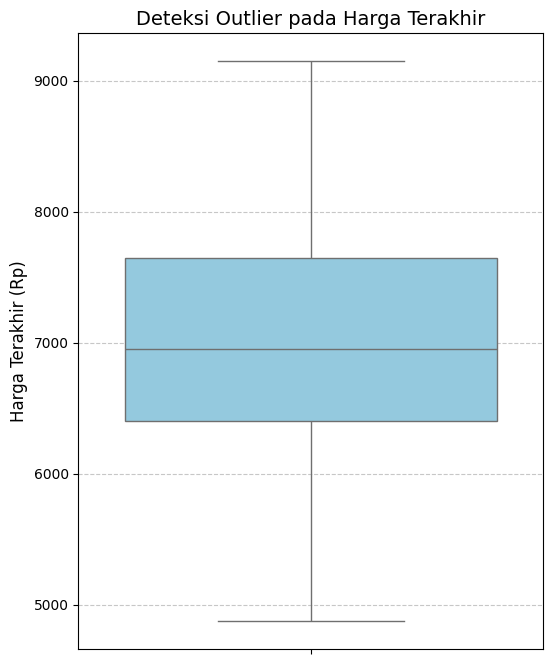

Batas Bawah: Rp4525
Batas Atas: Rp9525
Jumlah data outlier: 0


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# DETEKSI OUTLIER DENGAN BOXPLOT
# ===============================
plt.figure(figsize=(6, 8)) # Dibalik jadi (lebar, tinggi) agar lebih enak dilihat secara vertikal

# Cukup ganti x jadi y di sini
sns.boxplot(y=data['Terakhir'], color='skyblue')

plt.title('Deteksi Outlier pada Harga Terakhir', fontsize=14)
plt.ylabel('Harga Terakhir (Rp)', fontsize=12) # Ganti label jadi sumbu y
plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid disesuaikan ke sumbu y
plt.show()

# --- Perhitungan IQR tetap sama ---
Q1 = data['Terakhir'].quantile(0.25)
Q3 = data['Terakhir'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = (Q1 - 1.5 * IQR).astype(int)
upper_bound = (Q3 + 1.5 * IQR).astype(int)

outliers = data[(data['Terakhir'] < lower_bound) | (data['Terakhir'] > upper_bound)]
print(f"Batas Bawah: Rp{lower_bound}")
print(f"Batas Atas: Rp{upper_bound}")
print(f"Jumlah data outlier: {len(outliers)}")

In [9]:
# Deskripsi data yang digunakan
print("Deskripsi Data:")
print(data.describe().round(2))

Deskripsi Data:
       Terakhir
count    2609.0
mean     7019.1
std       792.6
min      4875.0
25%      6400.0
50%      6950.0
75%      7650.0
max      9150.0


In [10]:
# Cek tanggal duplikat
data = data.groupby('Tanggal').mean().reset_index()
is_duplicate = data['Tanggal'].duplicated().any()
print(f"\nIs duplicate? {is_duplicate}")


Is duplicate? False


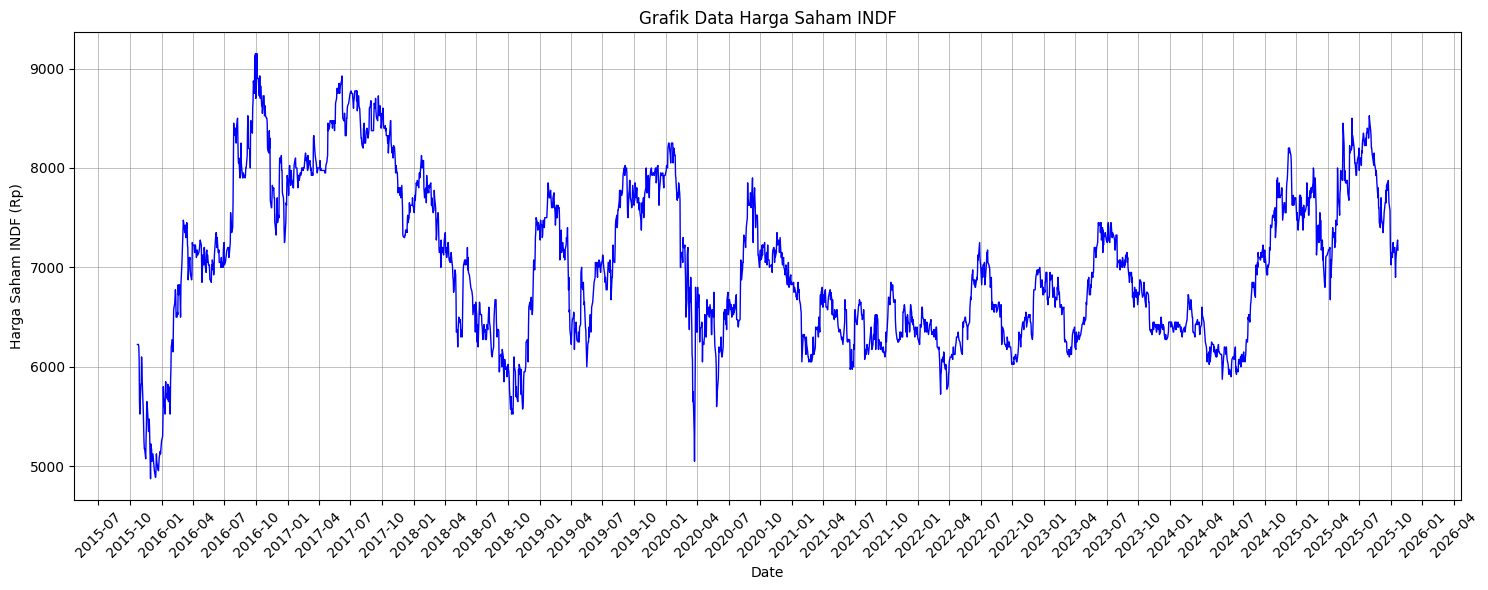

In [11]:
"""#Grafik Data"""

# Membuat plot data
plt.figure(figsize=(15,6))
plt.plot(data['Tanggal'], data['Terakhir'], color='blue', linewidth=1)

# Menambahkan judul dan label sumbu
plt.title('Grafik Data Harga Saham INDF')
plt.xlabel('Date')
plt.ylabel('Harga Saham INDF (Rp)')

# Atur sumbu x agar mudah dibaca
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Menampilkan tanggal setiap 3 bulan
plt.xticks(rotation=45)
plt.tight_layout()

# Menambahkan grid
plt.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.7)

# Menampilkan plot
plt.show()

In [12]:
import subprocess
import sys
try:
    import tcn
    print("Keras-TCN sudah terpasang, siap digunakan.")
except ImportError:
    print("Keras-TCN tidak ditemukan. Sedang menginstall...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tcn"])
    import tcn
    print("Instalasi selesai!")

Keras-TCN sudah terpasang, siap digunakan.



🔥 KOMBINASI 0.6-0.2-0.2
Train: (1558, 12, 1), Val: (519, 12, 1), Test: (520, 12, 1)
Total kombinasi: 32

➡️ Kombinasi 1
MAPE TEST: 1.17%

➡️ Kombinasi 2
MAPE TEST: 1.11%

➡️ Kombinasi 3
MAPE TEST: 1.11%

➡️ Kombinasi 4
MAPE TEST: 1.10%

➡️ Kombinasi 5
MAPE TEST: 1.10%

➡️ Kombinasi 6
MAPE TEST: 1.15%

➡️ Kombinasi 7
MAPE TEST: 1.13%

➡️ Kombinasi 8
MAPE TEST: 1.15%

➡️ Kombinasi 9
MAPE TEST: 1.13%

➡️ Kombinasi 10
MAPE TEST: 1.17%

➡️ Kombinasi 11
MAPE TEST: 1.08%

➡️ Kombinasi 12
MAPE TEST: 1.08%

➡️ Kombinasi 13
MAPE TEST: 1.22%

➡️ Kombinasi 14
MAPE TEST: 1.15%

➡️ Kombinasi 15
MAPE TEST: 1.11%

➡️ Kombinasi 16
MAPE TEST: 1.15%

➡️ Kombinasi 17
MAPE TEST: 1.08%

➡️ Kombinasi 18
MAPE TEST: 1.07%

➡️ Kombinasi 19
MAPE TEST: 1.11%

➡️ Kombinasi 20
MAPE TEST: 1.06%

➡️ Kombinasi 21
MAPE TEST: 1.12%

➡️ Kombinasi 22
MAPE TEST: 1.07%

➡️ Kombinasi 23
MAPE TEST: 1.09%

➡️ Kombinasi 24
MAPE TEST: 1.11%

➡️ Kombinasi 25
MAPE TEST: 1.07%

➡️ Kombinasi 26
MAPE TEST: 1.08%

➡️ Kombinasi 27
MAP

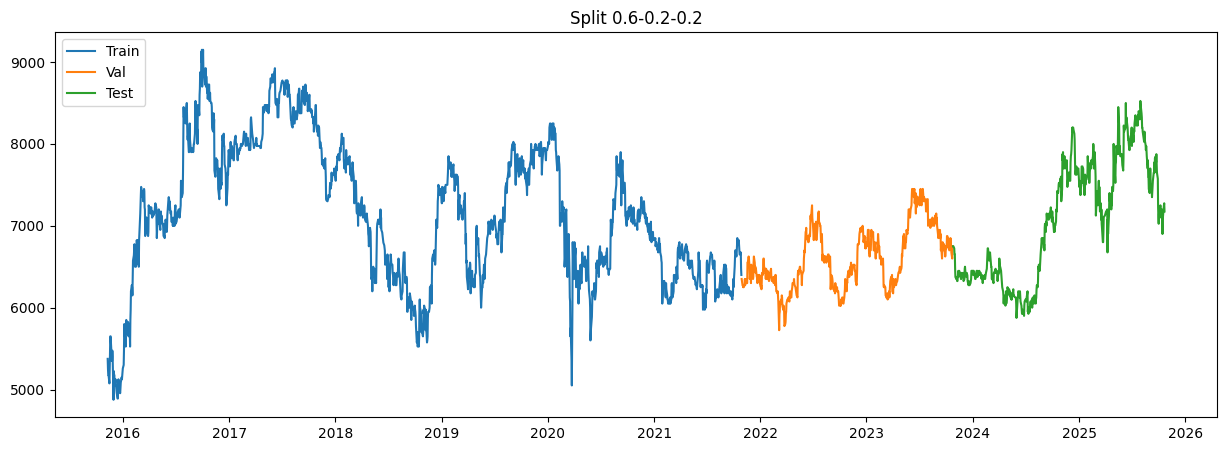

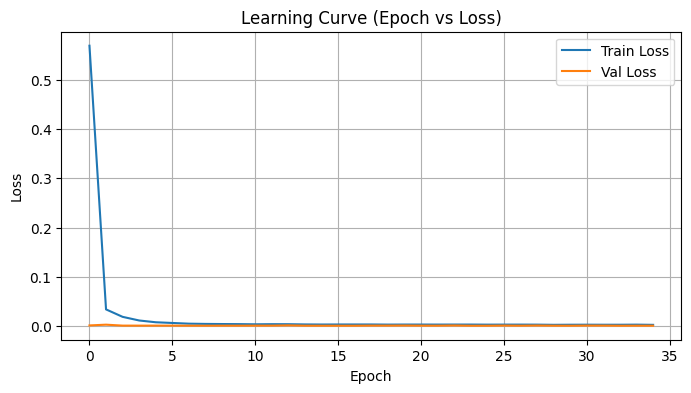

Best epoch: 33

🔥 KOMBINASI 0.7-0.15-0.15
Train: (1817, 12, 1), Val: (389, 12, 1), Test: (391, 12, 1)
Total kombinasi: 32

➡️ Kombinasi 1
MAPE TEST: 1.25%

➡️ Kombinasi 2
MAPE TEST: 1.22%

➡️ Kombinasi 3
MAPE TEST: 1.20%

➡️ Kombinasi 4
MAPE TEST: 1.19%

➡️ Kombinasi 5
MAPE TEST: 1.18%

➡️ Kombinasi 6
MAPE TEST: 1.32%

➡️ Kombinasi 7
MAPE TEST: 1.21%

➡️ Kombinasi 8
MAPE TEST: 1.32%

➡️ Kombinasi 9
MAPE TEST: 1.19%

➡️ Kombinasi 10
MAPE TEST: 1.22%

➡️ Kombinasi 11
MAPE TEST: 1.22%

➡️ Kombinasi 12
MAPE TEST: 1.33%

➡️ Kombinasi 13
MAPE TEST: 1.21%

➡️ Kombinasi 14
MAPE TEST: 1.35%

➡️ Kombinasi 15
MAPE TEST: 1.26%

➡️ Kombinasi 16
MAPE TEST: 1.29%

➡️ Kombinasi 17
MAPE TEST: 1.20%

➡️ Kombinasi 18
MAPE TEST: 1.23%

➡️ Kombinasi 19
MAPE TEST: 1.20%

➡️ Kombinasi 20
MAPE TEST: 1.22%

➡️ Kombinasi 21
MAPE TEST: 1.25%

➡️ Kombinasi 22
MAPE TEST: 1.22%

➡️ Kombinasi 23
MAPE TEST: 1.22%

➡️ Kombinasi 24
MAPE TEST: 1.22%

➡️ Kombinasi 25
MAPE TEST: 1.30%

➡️ Kombinasi 26
MAPE TEST: 1.31%

➡️

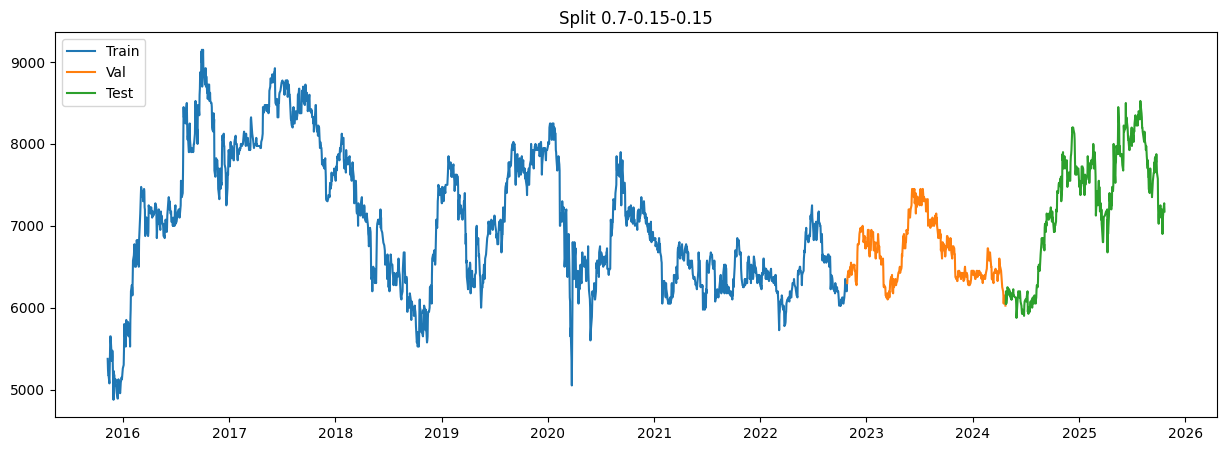

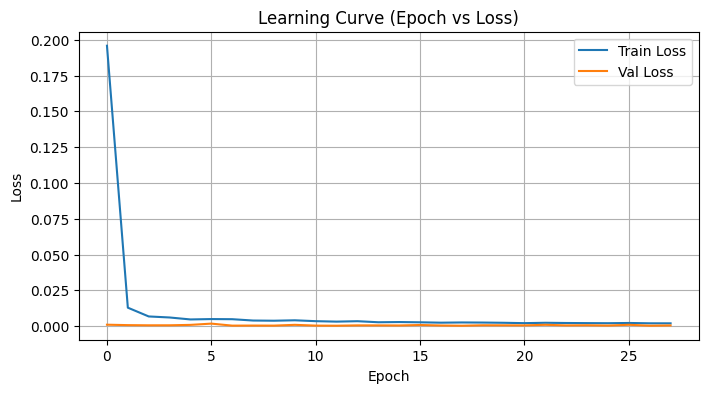

Best epoch: 18

🔥 KOMBINASI 0.8-0.1-0.1
Train: (2077, 12, 1), Val: (259, 12, 1), Test: (261, 12, 1)
Total kombinasi: 32

➡️ Kombinasi 1
MAPE TEST: 1.39%

➡️ Kombinasi 2
MAPE TEST: 1.41%

➡️ Kombinasi 3
MAPE TEST: 1.37%

➡️ Kombinasi 4
MAPE TEST: 1.36%

➡️ Kombinasi 5
MAPE TEST: 1.30%

➡️ Kombinasi 6
MAPE TEST: 1.43%

➡️ Kombinasi 7
MAPE TEST: 1.42%

➡️ Kombinasi 8
MAPE TEST: 1.35%

➡️ Kombinasi 9
MAPE TEST: 1.53%

➡️ Kombinasi 10
MAPE TEST: 1.36%

➡️ Kombinasi 11
MAPE TEST: 1.31%

➡️ Kombinasi 12
MAPE TEST: 1.30%

➡️ Kombinasi 13
MAPE TEST: 1.50%

➡️ Kombinasi 14
MAPE TEST: 1.33%

➡️ Kombinasi 15
MAPE TEST: 1.46%

➡️ Kombinasi 16
MAPE TEST: 1.40%

➡️ Kombinasi 17
MAPE TEST: 1.45%

➡️ Kombinasi 18
MAPE TEST: 1.39%

➡️ Kombinasi 19
MAPE TEST: 1.34%

➡️ Kombinasi 20
MAPE TEST: 1.34%

➡️ Kombinasi 21
MAPE TEST: 1.39%

➡️ Kombinasi 22
MAPE TEST: 1.39%

➡️ Kombinasi 23
MAPE TEST: 1.34%

➡️ Kombinasi 24
MAPE TEST: 1.35%

➡️ Kombinasi 25
MAPE TEST: 1.38%

➡️ Kombinasi 26
MAPE TEST: 1.34%

➡️ K

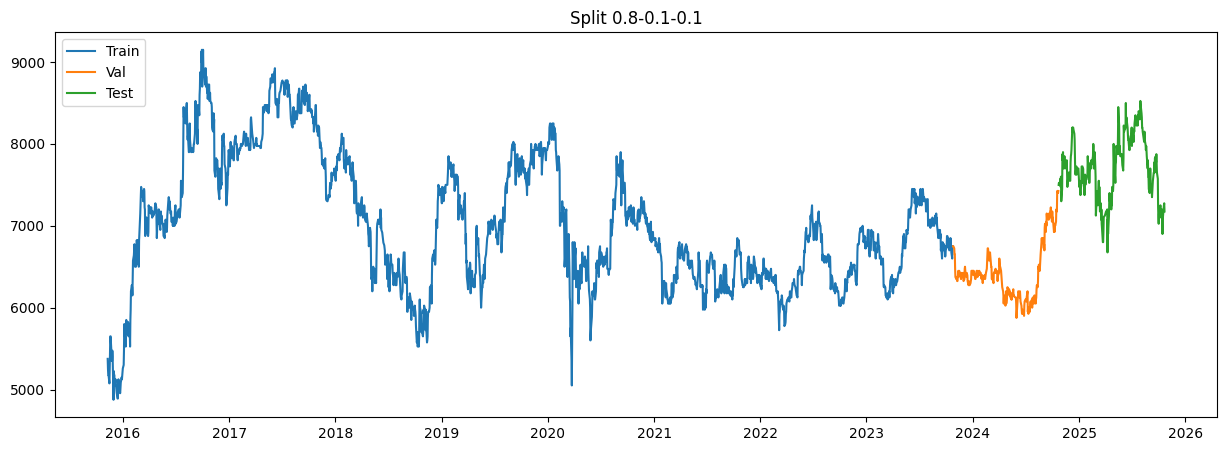

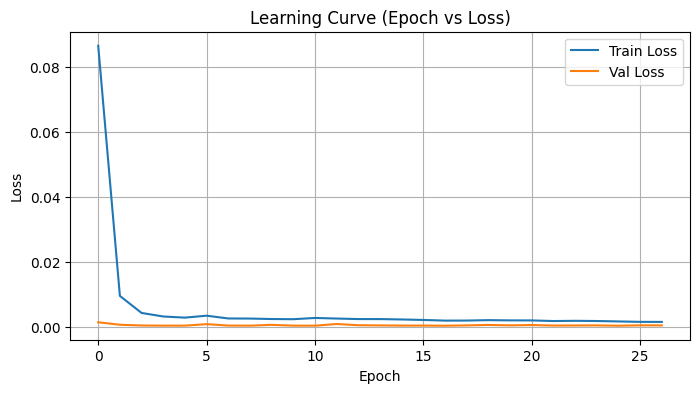

Best epoch: 17

📊 PERBANDINGAN SKENARIO:


,split,best_mape,best_params,best_epoch,training_time_sec
0,0.6-0.2-0.2,1.058021,"(64, 2, (1, 2, 4), 0.1, 16, 0.0015)",33,302.357136
1,0.7-0.15-0.15,1.180739,"(32, 2, (1, 2, 4), 0.2, 8, 0.001)",18,332.979425
2,0.8-0.1-0.1,1.304442,"(32, 3, (1, 2, 4), 0.1, 16, 0.0015)",17,328.496797



⏱️ Total Running Time: 964.17 seconds
≈ 16.07 minutes

TABEL 1: HASIL HYPERPARAMETER TUNING (TRAINING)


,Kombinasi Ke-,Split,Filter,Kernel,Batch Size,LR,Best Epoch,MAPE (%),Time (sec)
0,1,0.6-0.2-0.2,32,2,8,0.0010,9,1.1718,5.73
1,2,0.6-0.2-0.2,32,2,8,0.0015,7,1.1109,5.36
2,3,0.6-0.2-0.2,32,2,16,0.0010,22,1.1059,6.61
3,4,0.6-0.2-0.2,32,2,16,0.0015,3,1.0980,3.67
4,5,0.6-0.2-0.2,32,2,8,0.0010,21,1.0987,8.67
...,...,...,...,...,...,...,...,...,...
91,28,0.8-0.1-0.1,64,3,16,0.0015,10,1.3658,9.78
92,29,0.8-0.1-0.1,64,3,8,0.0010,5,1.4160,9.93
93,30,0.8-0.1-0.1,64,3,8,0.0015,26,1.4112,20.21
94,31,0.8-0.1-0.1,64,3,16,0.0010,12,1.3569,10.22



TABEL 2: HASIL TESTING FINAL (BEST PARAMS PER SKENARIO)


,split,rmse,mae,mape,r2
0,0.6-0.2-0.2,108.526292,76.032320,1.058021,0.977920
1,0.7-0.15-0.15,119.133676,86.687268,1.180739,0.972629
2,0.8-0.1-0.1,135.281609,99.522974,1.304442,0.874250


In [13]:
# ===============================
# 1. PREPROCESSING
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input

from tcn import TCN
import itertools

start_time_total = time.time()
tf.random.set_seed(1234)

# ===============================
# 2. SPLIT CONFIG
# ===============================
split_configs = [
    (0.6, 0.2, 0.2),
    (0.7, 0.15, 0.15),
    (0.8, 0.1, 0.1)
]

all_results = []

# ===============================
# 3. HYPERPARAMETER SPACE
# ===============================
tcn_filters = [32, 64]
tcn_kernel_sizes = [2, 3]
tcn_dilations = [(1, 2, 4)]
dropout_rates = [0.1, 0.2]
batch_sizes = [8, 16]
learning_rates = [0.001, 0.0015]

hyperparameter_combinations = list(itertools.product(
    tcn_filters, tcn_kernel_sizes, tcn_dilations,
    dropout_rates, batch_sizes, learning_rates
))
tuning_table_data = []
testing_table_data = []

# ===============================
# 4. SEQUENCE HELPER FUNCTION
# ===============================
def make_sequences(scaled, seq_len):
    X, y = [], []
    for i in range(len(scaled) - seq_len):
        X.append(scaled[i:i+seq_len])
        y.append(scaled[i+seq_len])
    return np.array(X), np.array(y)

raw = data[['Terakhir']].values   # data mentah, BELUM discale
sequence_length = 12

# ===============================
# 5. LOOP SPLIT
# ===============================
global_best_mape = float('inf')
global_best_model = None
global_best_split = None
best_history = None
best_metrics = {}

for train_ratio, val_ratio, test_ratio in split_configs:

    best_history = None
    print(f"\n🔥 KOMBINASI {train_ratio}-{val_ratio}-{test_ratio}")
    start_time_split = time.time()

    # ===============================
    # SPLIT DATA
    # ===============================

    # 1. Hitung ukuran split dari data mentah
    n_total = len(raw) - sequence_length   # sama dengan len(X) nanti
    train_size = int(n_total * train_ratio)
    val_size   = int(n_total * val_ratio)

    train_size_raw = train_size + sequence_length  # +12 karena sequence butuh lookback

    # 2. FIT scaler hanya dari data train (mentah)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(raw[:train_size_raw])

    # 3. TRANSFORM semua data pakai scaler yang sama
    scaledDataMat = scaler.transform(raw)

    # 4. Buat sequence SETELAH scaling
    X, y = make_sequences(scaledDataMat, sequence_length)

    # 5. Split X dan y
    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # ===============================
    # RESET BEST MODEL
    # ===============================
    results = []
    best_mape = float('inf')
    best_model = None
    best_params = None

    print(f"Total kombinasi: {len(hyperparameter_combinations)}")

    # ===============================
    # LOOP HYPERPARAMETER
    # ===============================
    for i, (tcn_filter, kernel_size, dilations, dropout_rate, batch_size_param, lr) in enumerate(hyperparameter_combinations):
        start_time_comb = time.time()
        split_name = f"{train_ratio}-{val_ratio}-{test_ratio}"
        print(f"\n➡️ Kombinasi {i+1}")

        try:
            tf.keras.backend.clear_session()

            model = Sequential()

            model.add(Input(shape=(sequence_length, 1)))

            model.add(TCN(
                nb_filters=tcn_filter,
                kernel_size=kernel_size,
                dilations=list(dilations),
                return_sequences=False,
                activation='relu',
                # input_shape=(sequence_length, 1),
                padding='causal'
            ))

            model.add(Dropout(dropout_rate))
            model.add(Dense(1))

            model.compile(
                optimizer=Adam(learning_rate=lr),
                loss='mse',
                metrics=['mae']
            )

            EPOCHS = 35
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )

            history = model.fit(
                X_train, y_train,
                epochs=EPOCHS,
                batch_size=batch_size_param,
                validation_data=(X_val, y_val),
                verbose=0,
                callbacks=[early_stopping]
            )
            end_time_comb = time.time()
            time_comb = end_time_comb - start_time_comb
            best_ep = np.argmin(history.history['val_loss']) + 1

            # ===============================
            # PREDICT
            # ===============================
            y_pred_train = model.predict(X_train, verbose=0)
            y_pred_val = model.predict(X_val, verbose=0)
            y_pred_test = model.predict(X_test, verbose=0)

            # ===============================
            # INVERSE SCALE
            # ===============================
            y_train_ori = scaler.inverse_transform(y_train)
            y_val_ori = scaler.inverse_transform(y_val)
            y_test_ori = scaler.inverse_transform(y_test)

            y_pred_train_ori = scaler.inverse_transform(y_pred_train)
            y_pred_val_ori = scaler.inverse_transform(y_pred_val)
            y_pred_test_ori = scaler.inverse_transform(y_pred_test)

            # ===============================
            # EVALUATION
            # ===============================
            mape_train = mean_absolute_percentage_error(y_train_ori, y_pred_train_ori) * 100
            mape_val = mean_absolute_percentage_error(y_val_ori, y_pred_val_ori) * 100
            mape_test = mean_absolute_percentage_error(y_test_ori, y_pred_test_ori) * 100

            tuning_table_data.append({
                "Kombinasi Ke-": i + 1,
                "Split": split_name,
                "Filter": tcn_filter,
                "Kernel": kernel_size,
                "Batch Size": batch_size_param,
                "LR": lr,
                "Best Epoch": best_ep,
                "MAPE (%)": round(mape_test, 4),
                "Time (sec)": round(time_comb, 2)
            })

            print(f"MAPE TEST: {mape_test:.2f}%")

            results.append([
                tcn_filter, kernel_size, str(dilations),
                dropout_rate, batch_size_param, lr,
                mape_train, mape_val, mape_test
            ])

            # ===============================
            # SAVE BEST MODEL (PER SPLIT)
            # ===============================
            if mape_test < best_mape:
                best_mape = mape_test
                best_model = tf.keras.models.clone_model(model)
                best_model.set_weights(model.get_weights())
                best_params = (tcn_filter, kernel_size, dilations, dropout_rate, batch_size_param, lr)
                best_history = history.history
                best_metrics = {
                    "split": split_name,
                    "rmse": np.sqrt(mean_squared_error(y_test_ori, y_pred_test_ori)),
                    "mae": mean_absolute_error(y_test_ori, y_pred_test_ori),
                    "mape": mape_test,
                    "r2": r2_score(y_test_ori, y_pred_test_ori)
                }

        except Exception as e:
            print("Error:", e)
            continue
    testing_table_data.append(best_metrics)
    # ===============================
    # HASIL PER SPLIT
    # ===============================
    print("\n🏆 BEST PARAMS:", best_params)
    print(f"BEST MAPE TEST: {best_mape:.2f}%")

    end_time_split = time.time()
    split_time = end_time_split - start_time_split

    all_results.append({
        "split": f"{train_ratio}-{val_ratio}-{test_ratio}",
        "best_mape": best_mape,
        "best_params": best_params,
        "best_epoch": np.argmin(best_history['val_loss']) + 1,
        "training_time_sec": split_time
    })

    print(f"⏱️ Waktu Split {train_ratio}-{val_ratio}-{test_ratio}: {split_time:.2f} detik")
    # ===============================
    # SAVE GLOBAL BEST MODEL
    # ===============================
    if best_mape < global_best_mape:
        global_best_mape = best_mape
        global_best_model = best_model
        global_best_split = (train_ratio, val_ratio, test_ratio)
        best_scaler = scaler
        best_scaledDataMat = scaledDataMat

        best_X_train = X_train
        best_X_val = X_val
        best_X_test = X_test

        best_y_train = y_train
        best_y_val = y_val
        best_y_test = y_test

        best_train_size = train_size
        best_val_size = val_size

    # ===============================
    # VISUALISASI
    # ===============================
    start_idx = sequence_length

    train_end = start_idx + train_size
    val_end = train_end + val_size

    data_train = df.iloc[start_idx:train_end]
    data_val = df.iloc[train_end:val_end]
    data_test = df.iloc[val_end:]

    plt.figure(figsize=(15,5))

    plt.plot(data_train['Tanggal'], data_train['Terakhir'], label='Train')
    plt.plot(data_val['Tanggal'], data_val['Terakhir'], label='Val')
    plt.plot(data_test['Tanggal'], data_test['Terakhir'], label='Test')

    plt.title(f"Split {train_ratio}-{val_ratio}-{test_ratio}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(best_history['loss'], label='Train Loss')
    plt.plot(best_history['val_loss'], label='Val Loss')

    plt.title("Learning Curve (Epoch vs Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

    print("Best epoch:", np.argmin(best_history['val_loss']) + 1)

# ===============================
# 7. RINGKASAN SEMUA SPLIT
# ===============================
summary_df = pd.DataFrame(all_results)
print("\n📊 PERBANDINGAN SKENARIO:")
display(summary_df)

end_time_total = time.time()
total_time = end_time_total - start_time_total

print(f"\n⏱️ Total Running Time: {total_time:.2f} seconds")
print(f"≈ {total_time/60:.2f} minutes")

# Tabel 1: Output Training & Tuning
print("\n" + "="*30)
print("TABEL 1: HASIL HYPERPARAMETER TUNING (TRAINING)")
print("="*30)
df_tuning = pd.DataFrame(tuning_table_data)
display(df_tuning) 

# Tabel 2: Output Testing Final
print("\n" + "="*30)
print("TABEL 2: HASIL TESTING FINAL (BEST PARAMS PER SKENARIO)")
print("="*30)
df_testing = pd.DataFrame(testing_table_data)
# Sesuai permintaan: RMSE, MAE, MAPE, R2
display(df_testing[['split', 'rmse', 'mae', 'mape', 'r2']])

In [14]:
import os
from openpyxl import load_workbook
from openpyxl.styles import numbers

os.makedirs("output_tunning", exist_ok=True)

df_tuning_export = df_tuning.copy()
df_tuning_export["LR"] = df_tuning_export["LR"].apply(lambda x: f"{x:.7f}".rstrip('0'))

# Simpan dulu tanpa format MAPE
df_tuning_export.to_excel("output_tunning/tabel_tuning_tcn.xlsx", index=False)

# Buka lagi dan format kolom MAPE manual
wb = load_workbook("output_tunning/tabel_tuning_tcn.xlsx")
ws = wb.active

# Cari index kolom MAPE
header = [cell.value for cell in ws[1]]
mape_col_idx = header.index("MAPE (%)") + 1  # +1 karena openpyxl 1-based

# Apply format 4 desimal ke semua baris data (mulai baris 2)
for row in ws.iter_rows(min_row=2, min_col=mape_col_idx, max_col=mape_col_idx):
    for cell in row:
        cell.number_format = '0.0000'  # ← 4 desimal

wb.save("output_tunning/tabel_tuning_tcn.xlsx")
print("✅ Tersimpan di output_tunning/tabel_tuning_tcn.xlsx")

✅ Tersimpan di output_tunning/tabel_tuning_tcn.xlsx


In [15]:
try:
    import tensorflow as tf
    print(f"TensorFlow sudah terinstall (Versi: {tf.__version__})")
except ImportError:
    print("TensorFlow belum ada, memulai instalasi...")
    import sys
    !{sys.executable} -m pip install tensorflow
    import tensorflow as tf
    print("Instalasi selesai!")

TensorFlow sudah terinstall (Versi: 2.21.0)


In [16]:
last_sequence = best_scaledDataMat[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

pred = global_best_model.predict(last_sequence)
pred_real = best_scaler.inverse_transform(pred) 

print("Forecast besok:", pred_real[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Forecast besok: 7161.612


In [17]:
# Predict
train_pred = global_best_model.predict(best_X_train)
test_pred = global_best_model.predict(best_X_test)
val_pred = global_best_model.predict(best_X_val)
# Inverse scaling (BALIK KE HARGA ASLI)
train_pred = best_scaler.inverse_transform(train_pred)
test_pred = best_scaler.inverse_transform(test_pred)
val_pred = best_scaler.inverse_transform(val_pred)

y_train_real = best_scaler.inverse_transform(best_y_train)
y_test_real = best_scaler.inverse_transform(best_y_test)
y_val_real = best_scaler.inverse_transform(best_y_val)

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:
import numpy as np

train_plot = np.empty(len(df))
train_plot[:] = np.nan

test_plot = np.empty(len(df))
test_plot[:] = np.nan

In [19]:
# Train
train_plot[sequence_length:best_train_size+sequence_length] = train_pred.flatten()

# Test
test_start = best_train_size + best_val_size + sequence_length
test_plot[test_start:test_start+len(best_y_test)] = test_pred.flatten()

# Validation
val_start = best_train_size + sequence_length
val_plot = np.empty(len(df))
val_plot[:] = np.nan
val_plot[val_start:val_start+len(val_pred)] = val_pred.flatten()

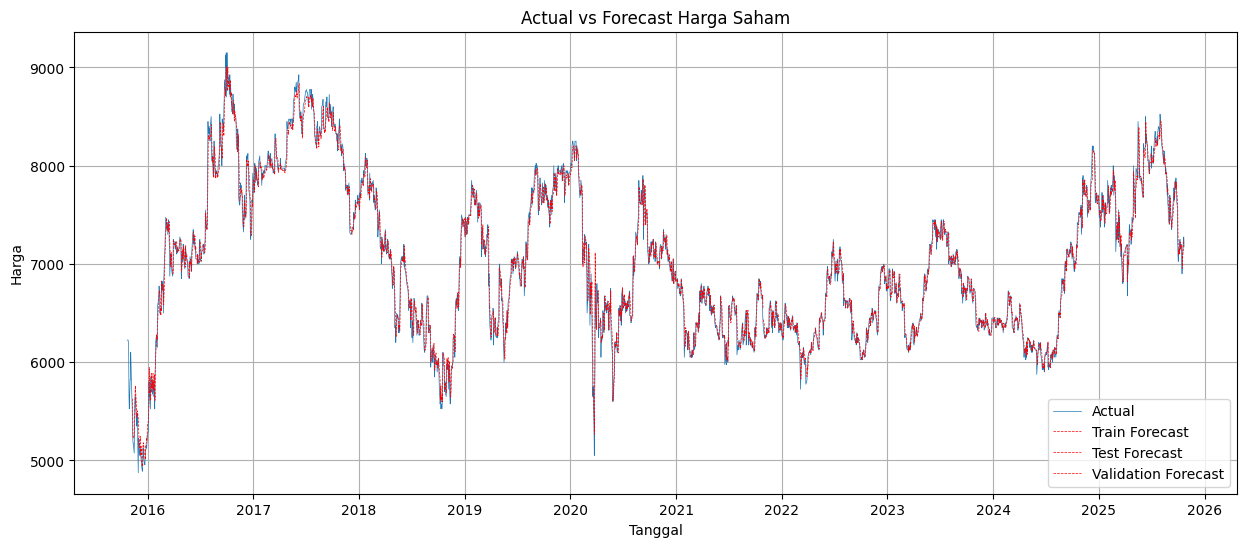

In [20]:
# ganti : grafik actual dan forecast aja (2 line only)
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Actual (DATA ASLI)
plt.plot(df['Tanggal'], df['Terakhir'], label='Actual', linewidth=0.5)

# Forecast
plt.plot(df['Tanggal'], train_plot, label='Train Forecast', color='red', linestyle='--', linewidth=0.5)
plt.plot(df['Tanggal'], test_plot, label='Test Forecast', color='red', linestyle='--', linewidth=0.5)
plt.plot(df['Tanggal'], val_plot, label='Validation Forecast', color='red', linestyle='--', linewidth=0.5)

plt.title("Actual vs Forecast Harga Saham")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

In [21]:
df_plot = df.copy()

# WAJIB: sort berdasarkan tanggal
df_plot['Tanggal'] = pd.to_datetime(df_plot['Tanggal'])
df_plot = df_plot.sort_values(by='Tanggal').reset_index(drop=True)
df_plot['Forecast'] = np.nan

# CARA BERSIH (Gunakan .iloc dengan index baris dan index kolom)
# index kolom 'Forecast' bisa didapat dengan df_plot.columns.get_loc('Forecast')
col_idx = df_plot.columns.get_loc('Forecast')

# Masukin train
df_plot.iloc[sequence_length:best_train_size+sequence_length, col_idx] = train_pred.flatten()

# Masukin test
df_plot.iloc[test_start:test_start+len(test_pred), col_idx] = test_pred.flatten()

# Masukin validation
val_idx_start = best_train_size + sequence_length
df_plot.iloc[val_idx_start : val_idx_start + len(val_pred), col_idx] = val_pred.flatten()

last_14 = df_plot.tail(30)

# next business day (biar gak kena weekend)
next_date = df['Tanggal'].iloc[-1] + pd.offsets.BDay(1)
next_value = pred_real[0][0]

In [22]:
print(test_pred[:10])       # prediksi best model (sudah di-inverse di cell 17)
print(y_test_real[:10])     # aktual best model (sudah di-inverse di cell 17)

[[6753.408 ]
 [6737.625 ]
 [6732.67  ]
 [6717.545 ]
 [6666.7754]
 [6653.695 ]
 [6537.419 ]
 [6429.77  ]
 [6381.511 ]
 [6387.1196]]
[[6750.]
 [6750.]
 [6725.]
 [6650.]
 [6650.]
 [6475.]
 [6375.]
 [6350.]
 [6375.]
 [6350.]]


In [23]:
rmse = np.sqrt(mean_squared_error(y_test_real, test_pred))
mae = mean_absolute_error(y_test_real, test_pred)
r2 = r2_score(y_test_real, test_pred)
mape = mean_absolute_percentage_error(y_test_real, test_pred) * 100

print(f"RMSE (Best Model)     : {rmse:.4f}")
print(f"MAE (Best Model)      : {mae:.4f}")
print(f"R² Score (Best Model) : {r2:.4f}")
print(f"MAPE (Best Model)     : {mape:.4f}%")
print(f"Forecast H+1          : Rp {pred_real[0][0]:,.3f}")

RMSE (Best Model)     : 108.5263
MAE (Best Model)      : 76.0323
R² Score (Best Model) : 0.9779
MAPE (Best Model)     : 1.0580%
Forecast H+1          : Rp 7,161.612


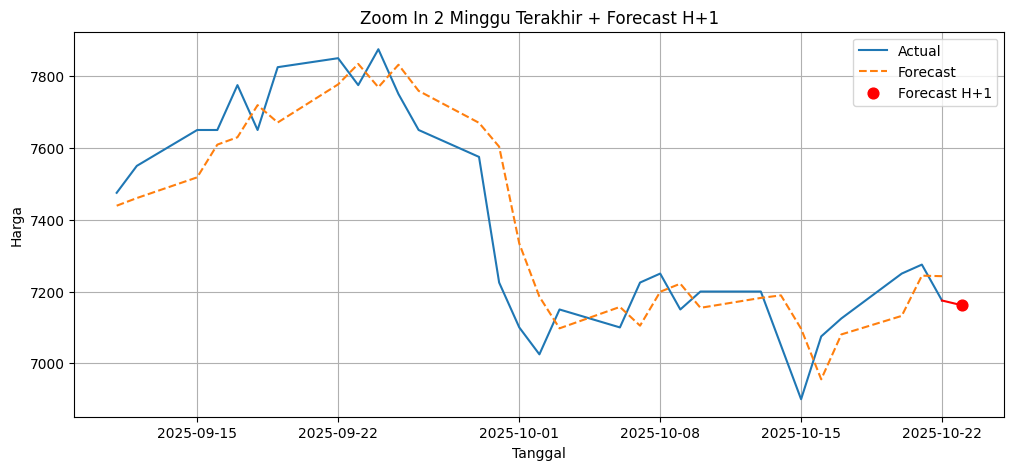

In [24]:
plt.figure(figsize=(12,5))

# actual
plt.plot(last_14['Tanggal'], last_14['Terakhir'], 
         label='Actual')

# forecast (overlap sama actual)
plt.plot(last_14['Tanggal'], last_14['Forecast'], 
         label='Forecast', linestyle='--')

# titik forecast H+1
plt.scatter(next_date, next_value, 
            color='red', label='Forecast H+1', s=60)

# garis bantu ke H+1
plt.plot([last_14['Tanggal'].iloc[-1], next_date],
         [last_14['Terakhir'].iloc[-1], next_value], color='red')

plt.title("Zoom In 2 Minggu Terakhir + Forecast H+1")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

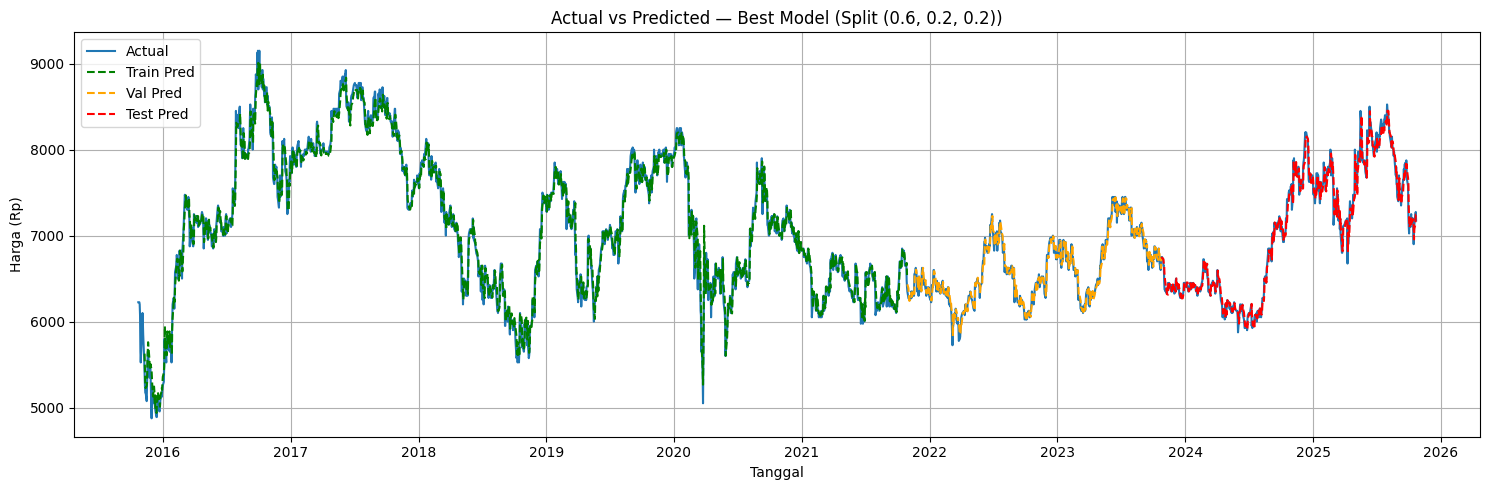

In [25]:
# Actual vs Predicted — seluruh periode
plt.figure(figsize=(15, 5))
plt.plot(df['Tanggal'], df['Terakhir'], label='Actual', linewidth=1.5)
plt.plot(df['Tanggal'], train_plot, label='Train Pred', color='green',  linestyle='--')
plt.plot(df['Tanggal'], val_plot,   label='Val Pred',   color='orange', linestyle='--')
plt.plot(df['Tanggal'], test_plot,  label='Test Pred',  color='red',    linestyle='--')
plt.title(f'Actual vs Predicted — Best Model (Split {global_best_split})')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [26]:
print("\nTABEL 4: TRAIN vs VAL vs TEST METRICS (GLOBAL BEST MODEL)")
train_pred = global_best_model.predict(best_X_train, verbose=0)
val_pred   = global_best_model.predict(best_X_val, verbose=0)
test_pred  = global_best_model.predict(best_X_test, verbose=0)

train_pred_ori = best_scaler.inverse_transform(train_pred)
val_pred_ori   = best_scaler.inverse_transform(val_pred)
# test_pred_ori  = best_scaler.inverse_transform(best_y_test)
y_train_ori    = best_scaler.inverse_transform(best_y_train)
y_val_ori      = best_scaler.inverse_transform(best_y_val)
y_test_ori     = best_scaler.inverse_transform(best_y_test)

test_pred_ori  = best_scaler.inverse_transform(
                     global_best_model.predict(best_X_test, verbose=0))

detail_metrics = pd.DataFrame([
    {
        "Data": "Train",
        "RMSE": np.sqrt(mean_squared_error(y_train_ori, train_pred_ori)),
        "MAE":  mean_absolute_error(y_train_ori, train_pred_ori),
        "MAPE": mean_absolute_percentage_error(y_train_ori, train_pred_ori) * 100,
        "R²":   r2_score(y_train_ori, train_pred_ori)
    },
    {
        "Data": "Validasi",
        "RMSE": np.sqrt(mean_squared_error(y_val_ori, val_pred_ori)),
        "MAE":  mean_absolute_error(y_val_ori, val_pred_ori),
        "MAPE": mean_absolute_percentage_error(y_val_ori, val_pred_ori) * 100,
        "R²":   r2_score(y_val_ori, val_pred_ori)
    },
    {
        "Data": "Test",
        "RMSE": np.sqrt(mean_squared_error(y_test_ori, test_pred_ori)),
        "MAE":  mean_absolute_error(y_test_ori, test_pred_ori),
        "MAPE": mean_absolute_percentage_error(y_test_ori, test_pred_ori) * 100,
        "R²":   r2_score(y_test_ori, test_pred_ori)
    }
])
display(detail_metrics)




TABEL 4: TRAIN vs VAL vs TEST METRICS (GLOBAL BEST MODEL)


,Data,RMSE,MAE,MAPE,R²
0,Train,121.822145,89.835434,1.283864,0.979967
1,Validasi,79.883318,60.265951,0.913701,0.954463
2,Test,108.526292,76.032320,1.058021,0.977920


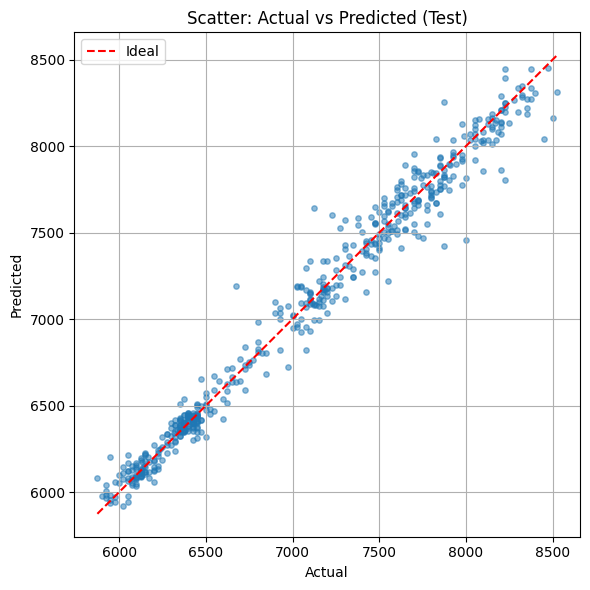

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_ori, test_pred_ori, alpha=0.5, s=15)
min_val = min(y_test_ori.min(), test_pred_ori.min())
max_val = max(y_test_ori.max(), test_pred_ori.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Scatter: Actual vs Predicted (Test)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

FORECAST 30 HARI KE DEPAN:


,Hari Ke-,Tanggal,Forecast Harga (Rp)
0,1,2025-10-23,7161
1,2,2025-10-24,7160
2,3,2025-10-27,7162
3,4,2025-10-28,7169
4,5,2025-10-29,7170
5,6,2025-10-30,7165
6,7,2025-10-31,7157
7,8,2025-11-03,7159
8,9,2025-11-04,7158
9,10,2025-11-05,7152


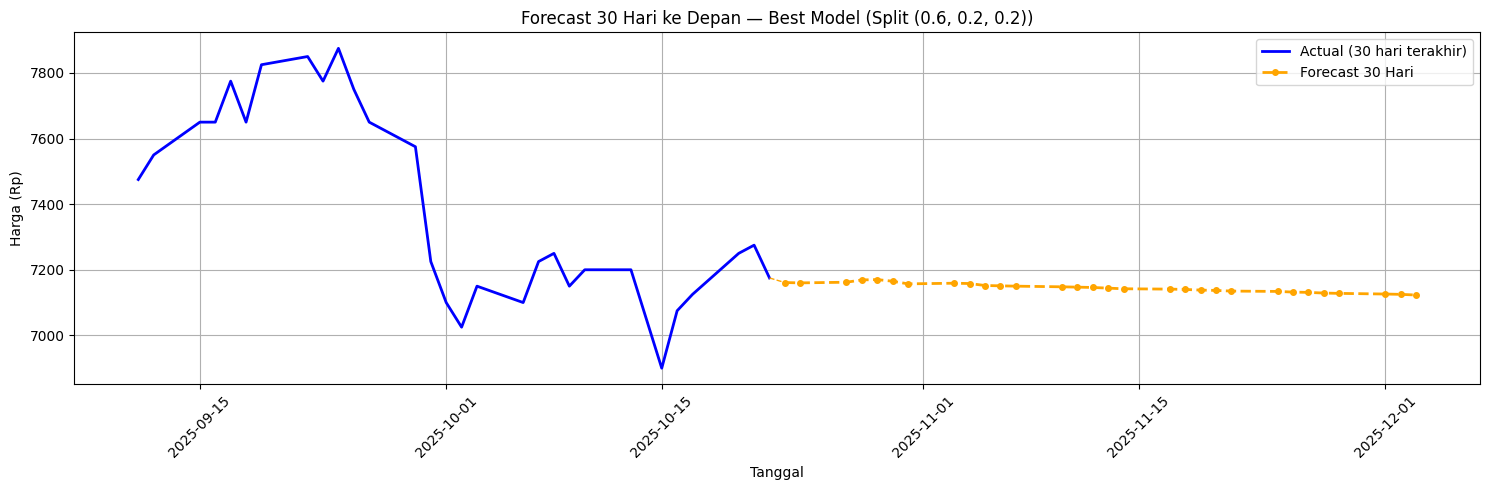


Harga Aktual Terakhir  : Rp 7175
Forecast Hari ke-1     : Rp 7161
Forecast Hari ke-30    : Rp 7123


In [28]:
# ===============================
# FORECAST 30 HARI KE DEPAN
# ===============================
forecast_days = 30
forecast_results = []

# Mulai dari sequence terakhir milik best split
current_sequence = best_scaledDataMat[-sequence_length:].copy()  # shape: (12, 1)

for day in range(forecast_days):
    # Reshape jadi (1, 12, 1) untuk input model
    input_seq = current_sequence.reshape(1, sequence_length, 1)
    
    # Prediksi 1 hari ke depan
    pred_scaled = global_best_model.predict(input_seq, verbose=0)
    
    # Inverse transform ke harga asli
    pred_price = best_scaler.inverse_transform(pred_scaled)[0][0]
    
    # Simpan tanggal dan harga prediksi
    next_date = df['Tanggal'].iloc[-1] + pd.offsets.BDay(day + 1)
    forecast_results.append({
        "Hari Ke-": day + 1,
        "Tanggal": next_date.strftime('%Y-%m-%d'),
        "Forecast Harga (Rp)": int(pred_price)
    })
    
    # Update sequence: geser 1, masukkan prediksi terbaru
    current_sequence = np.roll(current_sequence, -1, axis=0)
    current_sequence[-1] = pred_scaled[0]

# Tampilkan tabel
df_forecast = pd.DataFrame(forecast_results)
print("FORECAST 30 HARI KE DEPAN:")
display(df_forecast)

# ===============================
# VISUALISASI FORECAST 30 HARI
# ===============================
# Ambil 30 hari terakhir data aktual sebagai konteks
last_actual = df.tail(30).copy()

forecast_dates = pd.to_datetime(df_forecast['Tanggal'])
forecast_prices = df_forecast['Forecast Harga (Rp)']

plt.figure(figsize=(15, 5))

# Data aktual (30 hari terakhir sebagai konteks)
plt.plot(last_actual['Tanggal'], last_actual['Terakhir'], 
         label='Actual (30 hari terakhir)', color='blue', linewidth=2)

# Garis penghubung actual → forecast
plt.plot([last_actual['Tanggal'].iloc[-1], forecast_dates.iloc[0]],
         [last_actual['Terakhir'].iloc[-1], forecast_prices.iloc[0]],
         color='orange', linestyle='--', linewidth=1)

# Forecast 30 hari
plt.plot(forecast_dates, forecast_prices, 
         label='Forecast 30 Hari', color='orange', linestyle='--', linewidth=2, marker='o', markersize=4)

plt.title(f'Forecast 30 Hari ke Depan — Best Model (Split {global_best_split})')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nHarga Aktual Terakhir  : Rp {df['Terakhir'].iloc[-1]}")
print(f"Forecast Hari ke-1     : Rp {df_forecast['Forecast Harga (Rp)'].iloc[0]:.0f}")
print(f"Forecast Hari ke-30    : Rp {df_forecast['Forecast Harga (Rp)'].iloc[-1]:.0f}")

In [ ]:
import pickle

# Simpan semua hasil yang dibutuhkan
results_to_save = {
    # Metrik
    "rmse":  rmse,
    "mae":   mae,
    "mape":  mape,
    "r2":    r2,
    # Forecast H+1
    "forecast_h1": pred_real[0][0],
    # Forecast 30 hari
    "forecast_30_dates":  df_forecast['Tanggal'].tolist(),
    "forecast_30_prices": df_forecast['Forecast Harga (Rp)'].tolist(),
    # Info tambahan
    "best_split": global_best_split,
    "last_actual_price": df['Terakhir'].iloc[-1],
    "last_actual_date":  df['Tanggal'].iloc[-1],
    # total time
    "total_time":       total_time,
    "tuning_times":     df_tuning["Time (sec)"].tolist(), 
    #all results per kombinasi
    "all_results": all_results,
    "tuning_table_data": tuning_table_data,  
}

# Ganti nama file sesuai notebook-nya
pickle.dump(results_to_save, open("results_tcn.pkl", "wb"))       # di notebook TCN
print("✅ Hasil disimpan!")

✅ Hasil disimpan!


: 